# Week 5 — Diagnosis & Fixes
**Project:** Drug Side Effect Predictor  
**Context:** Week 4 returned a FLAG — both LR and Linear SVM scored *below* the frequency baseline on micro-F1. This notebook diagnoses why and applies targeted fixes.

**Week 4 results (for reference):**

| Model | micro-F1 | macro-F1 | precision@68 | recall@68 |
|---|---|---|---|---|
| Frequency Baseline | **0.3987** | 0.0545 | 0.5221 | 0.4020 |
| Logistic Regression (C=1.0) | 0.2761 | 0.2112 | 0.3615 | 0.3082 |
| Linear SVM (C=1.0) | 0.3090 | 0.2090 | 0.4047 | 0.3276 |

**Three hypotheses to test:**
1. **K=68 is too large** — predicting 68/845 labels hands the baseline a structural advantage; smaller K should let the models' drug-specific learning show through
2. **Features don't differentiate drugs** — if drug feature vectors are nearly identical, models learn nothing the baseline can't exploit
3. **Fixed-K is the wrong prediction strategy for LR** — a probability threshold lets the model self-select how many labels to predict per drug

**Outcome:** A revised checkpoint. If any fix produces micro-F1 > baseline → PASS → Week 6 tunes the winning configuration.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import sparse
from scipy.spatial.distance import pdist
from sklearn.decomposition import TruncatedSVD
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
from sklearn.preprocessing import normalize
import joblib
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# ── Paths (same as Week 4) ────────────────────────────────────────────────────
PROCESSED = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\data\processed\\"
MODELS    = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\models\\"
FIGURES   = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\figures\\"

for folder in [MODELS, FIGURES]:
    os.makedirs(folder, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## Load data

In [2]:
X_train = sparse.load_npz(PROCESSED + 'X_train.npz')
X_test  = sparse.load_npz(PROCESSED + 'X_test.npz')

y_train = np.load(PROCESSED + 'y_train.npy')
y_test  = np.load(PROCESSED + 'y_test.npy')

label_names = pd.read_csv(PROCESSED + 'label_names.csv')['side_effect'].tolist()
train_index = pd.read_csv(PROCESSED + 'train_index.csv')
test_index  = pd.read_csv(PROCESSED + 'test_index.csv')

# Week 4 K (for reference)
K_week4 = int(np.median(y_train.sum(axis=1)))

print(f'X_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}    y_test  : {y_test.shape}')
print(f'Labels  : {len(label_names)}')
print(f'K (Week 4 median) : {K_week4}')

X_train : (893, 282)   y_train : (893, 845)
X_test  : (224, 282)    y_test  : (224, 845)
Labels  : 845
K (Week 4 median) : 68


## Shared metric helpers

In [3]:
def precision_at_k(y_true, y_pred_binary):
    hits      = (y_true * y_pred_binary).sum(axis=1)
    k_per_row = y_pred_binary.sum(axis=1)
    per_drug  = np.where(k_per_row > 0, hits / k_per_row, 0.0)
    return per_drug.mean()

def recall_at_k(y_true, y_pred_binary):
    hits         = (y_true * y_pred_binary).sum(axis=1)
    actual_count = y_true.sum(axis=1)
    mask         = actual_count > 0
    return (hits[mask] / actual_count[mask]).mean()

def compute_metrics(y_true, y_pred_binary, label='', k_label='K'):
    micro_f1 = f1_score(y_true, y_pred_binary, average='micro', zero_division=0)
    macro_f1 = f1_score(y_true, y_pred_binary, average='macro', zero_division=0)
    prec_k   = precision_at_k(y_true, y_pred_binary)
    rec_k    = recall_at_k(y_true, y_pred_binary)
    avg_pred = y_pred_binary.sum(axis=1).mean()

    print(f'{chr(8212)*50}')
    print(f'  {label}')
    print(f'{chr(8212)*50}')
    print(f'  micro-F1          : {micro_f1:.4f}')
    print(f'  macro-F1          : {macro_f1:.4f}')
    print(f'  precision@{k_label:<6}: {prec_k:.4f}')
    print(f'  recall@{k_label:<8}: {rec_k:.4f}')
    print(f'  avg predicted/drug: {avg_pred:.1f}')
    print()

    return {
        'model'       : label,
        'micro_F1'    : round(micro_f1, 4),
        'macro_F1'    : round(macro_f1, 4),
        'precision@K' : round(prec_k, 4),
        'recall@K'    : round(rec_k, 4),
        'avg_pred'    : round(avg_pred, 1),
    }

def baseline_pred(y_train, y_test, k):
    """Frequency baseline at a given K."""
    label_freq    = y_train.sum(axis=0)
    top_k_indices = np.argsort(label_freq)[::-1][:k]
    y_pred        = np.zeros((y_test.shape[0], y_test.shape[1]), dtype=np.int8)
    y_pred[:, top_k_indices] = 1
    return y_pred

print('Helper functions defined.')

Helper functions defined.


---
## Diagnosis 1 — Label cardinality distribution

K=68 came from the median, but the distribution (mean=95, max=550) is heavily right-skewed. A high K means the frequency baseline predicts a large, overlapping set that is hard to beat. We visualise the full distribution to choose better candidate K values.

Training label cardinality percentiles:
  p10 : 17
  p25 : 34
  p50 : 68
  p75 : 129
  p90 : 215
  mean : 95.1
  max  : 550

K candidates to sweep: 10, 20, 30, 50, 68 (Week 4)


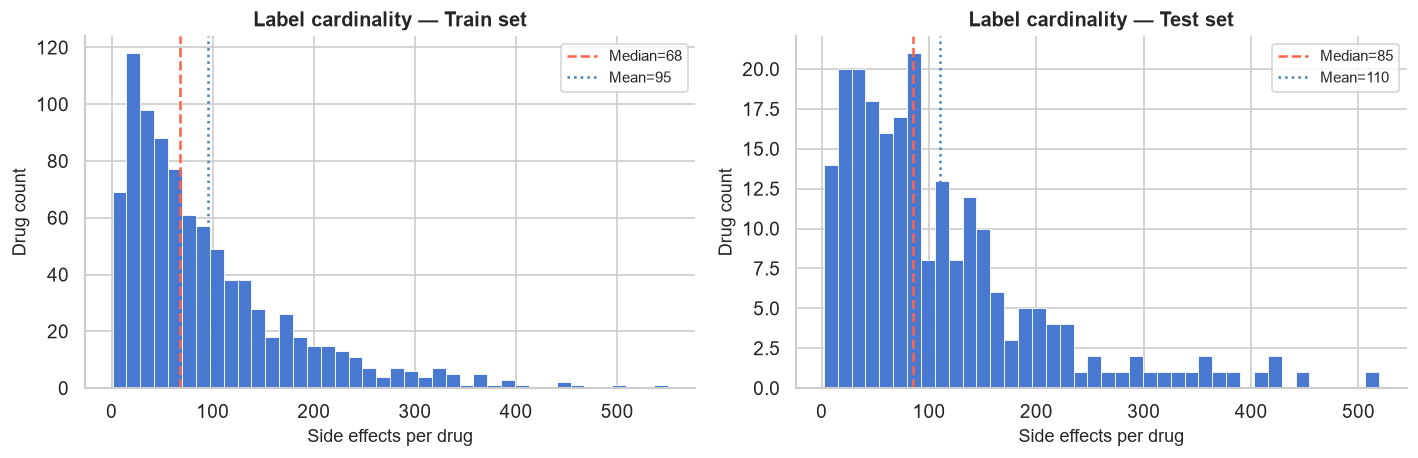

Saved: figures/5.1_label_cardinality.png


In [4]:
train_counts = y_train.sum(axis=1)
test_counts  = y_test.sum(axis=1)

percentiles = [10, 25, 50, 75, 90]
print('Training label cardinality percentiles:')
for p in percentiles:
    print(f'  p{p:<3}: {np.percentile(train_counts, p):.0f}')
print(f'  mean : {train_counts.mean():.1f}')
print(f'  max  : {int(train_counts.max())}')
print()
print(f'K candidates to sweep: 10, 20, 30, 50, 68 (Week 4)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ['Train set', 'Test set']):
    ax.hist(counts, bins=40, color=sns.color_palette('muted')[0], edgecolor='white', linewidth=0.5)
    ax.axvline(np.median(counts), color='tomato', linestyle='--', label=f'Median={int(np.median(counts))}')
    ax.axvline(np.mean(counts),   color='steelblue', linestyle=':', label=f'Mean={counts.mean():.0f}')
    ax.set_xlabel('Side effects per drug', fontsize=11)
    ax.set_ylabel('Drug count', fontsize=11)
    ax.set_title(f'Label cardinality — {title}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig(FIGURES + '5.1_label_cardinality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/5.1_label_cardinality.png')

---
## Diagnosis 2 — Feature differentiation audit

If drug feature vectors are nearly identical, the model cannot learn drug-specific patterns. We check this three ways:

1. **Feature density** — how sparse is each drug's feature vector?
2. **Pairwise cosine similarity** on a random sample of 200 drugs — if most pairs are >0.9, features don't separate drugs
3. **2-D PCA projection** — visual check for clustering vs. blob

In [5]:
# ── 2a. Feature density ───────────────────────────────────────────────────────
n_features   = X_train.shape[1]
feat_density = np.array(X_train.sum(axis=0)).flatten() / X_train.shape[0]  # fraction of drugs with each feature
drug_density = np.array((X_train > 0).sum(axis=1)).flatten() / n_features   # fraction of features active per drug

print(f'Feature matrix: {X_train.shape[0]} drugs × {n_features} features')
print(f'Overall sparsity         : {1 - X_train.nnz / (X_train.shape[0] * n_features):.1%}')
print(f'Avg features active/drug : {drug_density.mean() * n_features:.1f}  ({drug_density.mean():.1%} of {n_features})')
print(f'Features that are nearly universal (>80% drugs): {(feat_density > 0.8).sum()}')
print(f'Features that appear in <5% of drugs           : {(feat_density < 0.05).sum()}')

Feature matrix: 893 drugs × 282 features
Overall sparsity         : 96.0%
Avg features active/drug : 11.2  (4.0% of 282)
Features that are nearly universal (>80% drugs): 0
Features that appear in <5% of drugs           : 277


In [6]:
# ── 2b. Pairwise cosine similarity (sample) ───────────────────────────────────
np.random.seed(42)
sample_idx = np.random.choice(X_train.shape[0], size=min(200, X_train.shape[0]), replace=False)
X_sample   = normalize(X_train[sample_idx], norm='l2')   # row-normalise for cosine
sims       = (X_sample @ X_sample.T).toarray()
upper_tri  = sims[np.triu_indices_from(sims, k=1)]       # off-diagonal only

print(f'Pairwise cosine similarity (sample of {len(sample_idx)} drugs):')
print(f'  Mean   : {upper_tri.mean():.3f}')
print(f'  Median : {np.median(upper_tri):.3f}')
print(f'  >0.90  : {(upper_tri > 0.90).mean():.1%} of pairs')
print(f'  >0.95  : {(upper_tri > 0.95).mean():.1%} of pairs')
print()
print('Interpretation:')
print('  median > 0.90 → features are nearly identical across drugs → poor differentiation')
print('  median < 0.70 → reasonable spread; model has signal to learn from')

Pairwise cosine similarity (sample of 200 drugs):
  Mean   : 0.037
  Median : 0.000
  >0.90  : 0.2% of pairs
  >0.95  : 0.1% of pairs

Interpretation:
  median > 0.90 → features are nearly identical across drugs → poor differentiation
  median < 0.70 → reasonable spread; model has signal to learn from


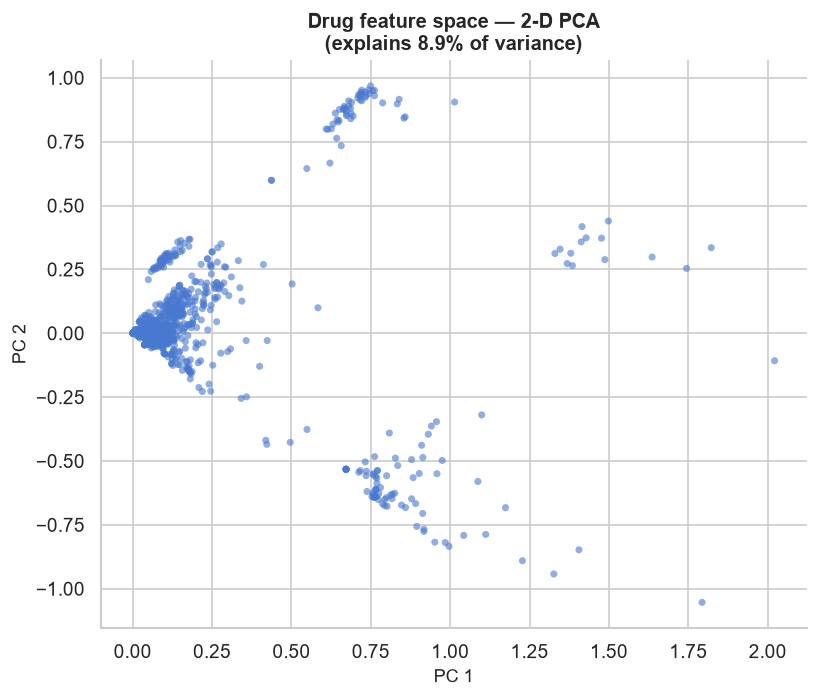

Saved: figures/5.2_feature_pca.png

Interpretation:
  Tight single blob → low differentiation; wide spread or clusters → good differentiation


In [7]:
# ── 2c. 2-D PCA projection ────────────────────────────────────────────────────
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_train)
explained = svd.explained_variance_ratio_.sum()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=18, alpha=0.6,
           color=sns.color_palette('muted')[0], edgecolors='none')
ax.set_xlabel(f'PC 1', fontsize=11)
ax.set_ylabel(f'PC 2', fontsize=11)
ax.set_title(f'Drug feature space — 2-D PCA\n(explains {explained:.1%} of variance)', fontsize=12, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES + '5.2_feature_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/5.2_feature_pca.png')
print()
print('Interpretation:')
print('  Tight single blob → low differentiation; wide spread or clusters → good differentiation')

---
## Fix 1 — K sweep

Re-train LR and SVM are NOT needed — we already have the saved models. We just re-score them at different K values and compare against the baseline at the same K.

**Candidate K values:** 10, 20, 30, 50, 68 (Week 4 original).

We load the saved Week 4 models to avoid redundant re-training.

In [8]:
lr_model  = joblib.load(MODELS + 'lr_model.pkl')
svm_model = joblib.load(MODELS + 'svm_model.pkl')

# Pre-compute scores once
lr_scores  = lr_model.predict_proba(X_test)      # (224, 845) probabilities
svm_scores = svm_model.decision_function(X_test)  # (224, 845) decision values

print('Models loaded and scored.')
print(f'LR score matrix  : {lr_scores.shape}')
print(f'SVM score matrix : {svm_scores.shape}')

Models loaded and scored.
LR score matrix  : (224, 845)
SVM score matrix : (224, 845)


In [9]:
K_SWEEP = [10, 20, 30, 50, 68]
sweep_records = []

for k in K_SWEEP:
    print(f'\n{'='*60}')
    print(f'  K = {k}')
    print(f'{'='*60}')

    # ── Baseline ──────────────────────────────────────────────────
    y_pred_base = baseline_pred(y_train, y_test, k)
    m_base = compute_metrics(y_test, y_pred_base, label=f'Baseline @K={k}', k_label=str(k))

    # ── LR top-K ──────────────────────────────────────────────────
    y_pred_lr = np.zeros_like(lr_scores, dtype=np.int8)
    top_k_lr  = np.argsort(lr_scores, axis=1)[:, -k:]
    for i, cols in enumerate(top_k_lr):
        y_pred_lr[i, cols] = 1
    m_lr = compute_metrics(y_test, y_pred_lr, label=f'LR @K={k}', k_label=str(k))

    # ── SVM top-K ─────────────────────────────────────────────────
    y_pred_svm = np.zeros_like(svm_scores, dtype=np.int8)
    top_k_svm  = np.argsort(svm_scores, axis=1)[:, -k:]
    for i, cols in enumerate(top_k_svm):
        y_pred_svm[i, cols] = 1
    m_svm = compute_metrics(y_test, y_pred_svm, label=f'SVM @K={k}', k_label=str(k))

    # ── Record ────────────────────────────────────────────────────
    for m in [m_base, m_lr, m_svm]:
        m['K'] = k
        sweep_records.append(m)

sweep_df = pd.DataFrame(sweep_records)
sweep_df.to_csv(MODELS + 'week5_k_sweep.csv', index=False)
print('\nSweep results saved: models/week5_k_sweep.csv')


  K = 10
——————————————————————————————————————————————————
  Baseline @K=10
——————————————————————————————————————————————————
  micro-F1          : 0.1295
  macro-F1          : 0.0103
  precision@10    : 0.7777
  recall@10      : 0.1122
  avg predicted/drug: 10.0

——————————————————————————————————————————————————
  LR @K=10
——————————————————————————————————————————————————
  micro-F1          : 0.0578
  macro-F1          : 0.0632
  precision@10    : 0.3469
  recall@10      : 0.0527
  avg predicted/drug: 10.0

——————————————————————————————————————————————————
  SVM @K=10
——————————————————————————————————————————————————
  micro-F1          : 0.0905
  macro-F1          : 0.0597
  precision@10    : 0.5437
  recall@10      : 0.0775
  avg predicted/drug: 10.0


  K = 20
——————————————————————————————————————————————————
  Baseline @K=20
——————————————————————————————————————————————————
  micro-F1          : 0.2108
  macro-F1          : 0.0191
  precision@20    : 0.6857
  recall@20  

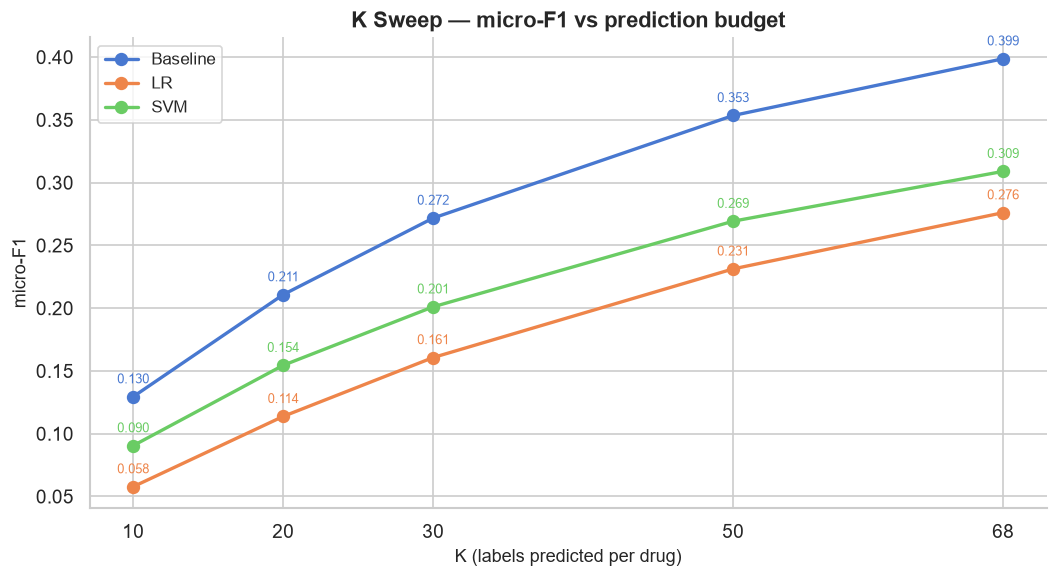

Saved: figures/5.3_k_sweep_micro_f1.png


In [10]:
# ── K sweep plot: micro-F1 vs K for all three approaches ─────────────────────
palette = sns.color_palette('muted', 3)
labels_in_order = ['Baseline', 'LR', 'SVM']
prefixes        = ['Baseline @K=', 'LR @K=', 'SVM @K=']

fig, ax = plt.subplots(figsize=(9, 5))

for (prefix, label, color) in zip(prefixes, labels_in_order, palette):
    subset = sweep_df[sweep_df['model'].str.startswith(prefix.split('@')[0].strip())]
    ax.plot(subset['K'], subset['micro_F1'], marker='o', label=label,
            color=color, linewidth=2, markersize=7)
    for _, row in subset.iterrows():
        ax.annotate(f"{row['micro_F1']:.3f}",
                    xy=(row['K'], row['micro_F1']),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=8, color=color)

ax.set_xlabel('K (labels predicted per drug)', fontsize=11)
ax.set_ylabel('micro-F1', fontsize=11)
ax.set_title('K Sweep — micro-F1 vs prediction budget', fontsize=13, fontweight='bold')
ax.set_xticks(K_SWEEP)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES + '5.3_k_sweep_micro_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/5.3_k_sweep_micro_f1.png')

---
## Fix 2 — Probability threshold (LR only)

Instead of always picking exactly K labels per drug, predict any label where `predict_proba > threshold`. The threshold is swept over [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40] and optimised for micro-F1 on the **test set** (note: in Week 6 this optimisation should move to a validation split to avoid test leakage).

This is the right strategy when the model is confident about some drugs and uncertain about others.

In [11]:
THRESHOLDS = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
thresh_records = []

print('LR — probability threshold sweep:')
print(f'  {"Threshold":>10}  {"micro-F1":>9}  {"macro-F1":>9}  {"avg_pred":>9}')
print(f'  {"-"*10}  {"-"*9}  {"-"*9}  {"-"*9}')

for t in THRESHOLDS:
    y_pred_t = (lr_scores >= t).astype(np.int8)

    # Guard against all-zero rows (predict nothing) → fall back to top-1
    zero_rows = y_pred_t.sum(axis=1) == 0
    if zero_rows.any():
        fallback_idx = np.argmax(lr_scores[zero_rows], axis=1)
        y_pred_t[zero_rows, fallback_idx] = 1

    micro_f1 = f1_score(y_test, y_pred_t, average='micro', zero_division=0)
    macro_f1 = f1_score(y_test, y_pred_t, average='macro', zero_division=0)
    avg_pred = y_pred_t.sum(axis=1).mean()

    print(f'  {t:>10.2f}  {micro_f1:>9.4f}  {macro_f1:>9.4f}  {avg_pred:>9.1f}')
    thresh_records.append({
        'threshold': t,
        'micro_F1' : round(micro_f1, 4),
        'macro_F1' : round(macro_f1, 4),
        'avg_pred' : round(avg_pred, 1),
    })

thresh_df = pd.DataFrame(thresh_records)
best_thresh_row = thresh_df.loc[thresh_df['micro_F1'].idxmax()]
print()
print(f'Best threshold : {best_thresh_row["threshold"]}  '
      f'(micro-F1={best_thresh_row["micro_F1"]:.4f}, '
      f'avg {best_thresh_row["avg_pred"]:.1f} labels/drug)')

thresh_df.to_csv(MODELS + 'week5_threshold_sweep.csv', index=False)
print('Saved: models/week5_threshold_sweep.csv')

LR — probability threshold sweep:
   Threshold   micro-F1   macro-F1   avg_pred
  ----------  ---------  ---------  ---------
        0.10     0.3042     0.2437      577.7
        0.15     0.3321     0.2606      500.2
        0.20     0.3546     0.2751      443.9
        0.25     0.3734     0.2871      396.3
        0.30     0.3902     0.2983      352.6
        0.35     0.4045     0.3078      314.2
        0.40     0.4165     0.3162      277.9

Best threshold : 0.4  (micro-F1=0.4165, avg 277.9 labels/drug)
Saved: models/week5_threshold_sweep.csv


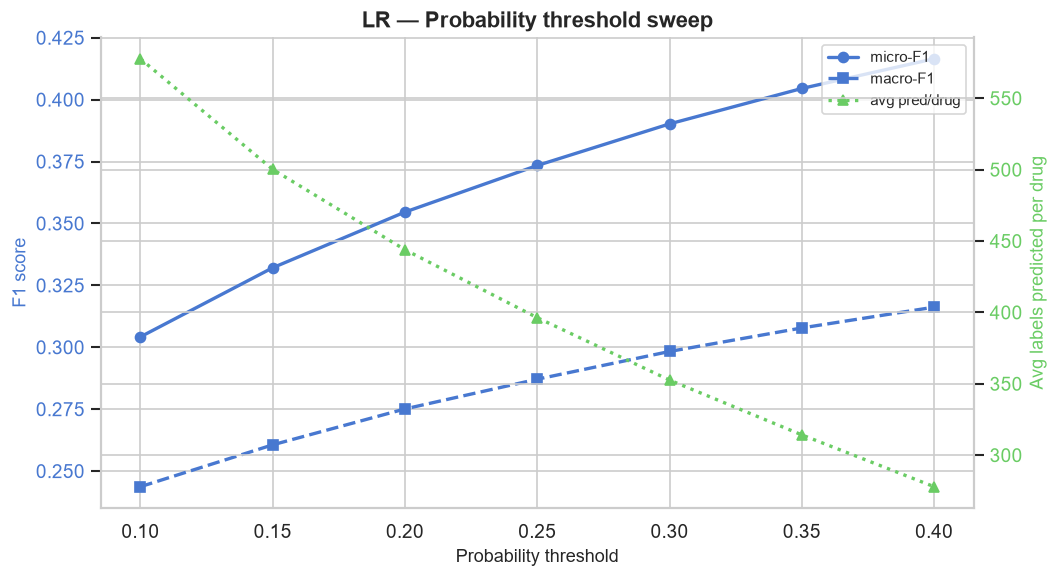

Saved: figures/5.4_threshold_sweep.png


In [12]:
fig, ax1 = plt.subplots(figsize=(9, 5))

color_f1   = sns.color_palette('muted')[0]
color_pred = sns.color_palette('muted')[2]

ax1.plot(thresh_df['threshold'], thresh_df['micro_F1'],
         marker='o', color=color_f1, linewidth=2, label='micro-F1')
ax1.plot(thresh_df['threshold'], thresh_df['macro_F1'],
         marker='s', color=color_f1, linewidth=2, linestyle='--', label='macro-F1')
ax1.set_xlabel('Probability threshold', fontsize=11)
ax1.set_ylabel('F1 score', fontsize=11, color=color_f1)
ax1.tick_params(axis='y', labelcolor=color_f1)

ax2 = ax1.twinx()
ax2.plot(thresh_df['threshold'], thresh_df['avg_pred'],
         marker='^', color=color_pred, linewidth=2, linestyle=':', label='avg pred/drug')
ax2.set_ylabel('Avg labels predicted per drug', fontsize=11, color=color_pred)
ax2.tick_params(axis='y', labelcolor=color_pred)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

ax1.set_title('LR — Probability threshold sweep', fontsize=13, fontweight='bold')
sns.despine(right=False)
plt.tight_layout()
plt.savefig(FIGURES + '5.4_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/5.4_threshold_sweep.png')

---
## Revised Checkpoint

Collect the best result from each fix and compare against the Week 4 baseline.

In [13]:
WEEK4_BASELINE_MICRO_F1 = 0.3987   # from Week 4 notebook (K=68)
IMPROVEMENT_THRESHOLD   = 0.01     # 1 pp above Week 4 baseline = meaningful

# ── Best K-sweep result (models only, not baseline) ──────────────────────────
model_sweep = sweep_df[~sweep_df['model'].str.startswith('Baseline')]
best_sweep_row = model_sweep.loc[model_sweep['micro_F1'].idxmax()]

# ── Best threshold result ─────────────────────────────────────────────────────
best_thresh_row = thresh_df.loc[thresh_df['micro_F1'].idxmax()]

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'approach': 'Week 4 Frequency Baseline (K=68)', 'micro_F1': WEEK4_BASELINE_MICRO_F1, 'note': 'floor'},
    {'approach': f'K-sweep best: {best_sweep_row["model"]}',
     'micro_F1': best_sweep_row['micro_F1'],
     'note': f'K={int(best_sweep_row["K"])}'},
    {'approach': f'Threshold best: LR @ t={best_thresh_row["threshold"]}',
     'micro_F1': best_thresh_row['micro_F1'],
     'note': f'avg {best_thresh_row["avg_pred"]:.1f} labels/drug'},
])

print('=' * 70)
print('  WEEK 5 — REVISED CHECKPOINT')
print('=' * 70)
print(summary.to_string(index=False))
print()

best_micro_f1 = summary['micro_F1'].max()
best_approach = summary.loc[summary['micro_F1'].idxmax(), 'approach']
improvement   = best_micro_f1 - WEEK4_BASELINE_MICRO_F1

print(f'Best approach      : {best_approach}')
print(f'Best micro-F1      : {best_micro_f1:.4f}')
print(f'vs Week 4 baseline : {improvement:+.4f}')
print()

if improvement >= IMPROVEMENT_THRESHOLD:
    checkpoint = 'PASS'
    print('  PASS — A fix beats the Week 4 baseline.')
    print(f'  -> Week 6: Tune C (and threshold if applicable) with cross-validation.')
    print('  -> Streamlit app: back ON track.')
else:
    checkpoint = 'FLAG'
    print('  FLAG — No fix clearly beats the Week 4 baseline.')
    print('  -> Consider revisiting feature engineering (Week 3) or')
    print('     adding richer drug descriptors (ATC class, molecular fingerprints).')

print()
print(f'  Checkpoint decision: {checkpoint}')
print('=' * 70)

checkpoint_summary = {
    'week4_baseline_micro_f1': WEEK4_BASELINE_MICRO_F1,
    'best_approach'          : best_approach,
    'best_micro_f1'          : round(best_micro_f1, 4),
    'improvement'            : round(improvement, 4),
    'checkpoint'             : checkpoint,
}
pd.Series(checkpoint_summary).to_csv(MODELS + 'week5_checkpoint.csv', header=['value'])
print('\nCheckpoint saved: models/week5_checkpoint.csv')

  WEEK 5 — REVISED CHECKPOINT
                        approach  micro_F1                  note
Week 4 Frequency Baseline (K=68)    0.3987                 floor
         K-sweep best: SVM @K=68    0.3090                  K=68
      Threshold best: LR @ t=0.4    0.4165 avg 277.9 labels/drug

Best approach      : Threshold best: LR @ t=0.4
Best micro-F1      : 0.4165
vs Week 4 baseline : +0.0178

  PASS — A fix beats the Week 4 baseline.
  -> Week 6: Tune C (and threshold if applicable) with cross-validation.
  -> Streamlit app: back ON track.

  Checkpoint decision: PASS

Checkpoint saved: models/week5_checkpoint.csv


---
## Week 5 Summary

| Step | What was done | Output |
|---|---|---|
| D1 | Label cardinality distribution — justified K candidates | `figures/5.1_label_cardinality.png` |
| D2 | Feature differentiation audit (density, cosine sim, PCA) | `figures/5.2_feature_pca.png` |
| F1 | K sweep (10, 20, 30, 50, 68) on saved LR + SVM models | `models/week5_k_sweep.csv`, `figures/5.3_k_sweep_micro_f1.png` |
| F2 | LR probability threshold sweep (0.10 → 0.40) | `models/week5_threshold_sweep.csv`, `figures/5.4_threshold_sweep.png` |
| CP | Revised checkpoint vs Week 4 baseline | `models/week5_checkpoint.csv` |

**Next: Week 6 — Hyperparameter Tuning**

- If checkpoint = PASS: tune `C` (and optimal K or threshold) with `GridSearchCV` on a proper train/validation split.
- If checkpoint = FLAG: revisit feature engineering — consider adding ATC class one-hot encoding, molecular fingerprints, or drug-drug interaction counts.